# MLP 10-class — OtrembaMLP (n_classes=10)

Phase 9: 기존 OtrembaMLP (4-class) 구조를 10-class로 확장한 실험.

- Architecture: 77 → 128 → 128 → 10 (기존 4-class와 동일, output만 확장)
- 목적: i.i.d. 비선형 모델의 10-class 한계 측정
- 4-class Model B (60.9%) 결과는 notebooks/03_model_b_otremba_2022.ipynb 참조

작성일: 2026-05-23

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = Path('../outputs')
data = np.load(OUTPUT_DIR / 'evaluation_mlp_10cls.npz', allow_pickle=True)

cls10 = ['Ball','Strike','Single','Double','Triple','HomeRun','FieldOut','Strikeout','Walk','HitByPitch']

print(f'Top-1: {float(data["top1"])*100:.1f}%')
print(f'Top-3: {float(data["top3"])*100:.1f}%')
print(f'CE:    {float(data["ce"]):.4f}')
print(f'Best val loss: {float(data["best_val_loss"]):.4f}')
print(f'Params: 27,786')

## 1. 결과 요약

| 지표 | 값 |
|------|----|
| Top-1 | 41.1% |
| Top-3 | 86.2% |
| CE | 1.4608 |
| 학습 epoch | 7 (early stopping) |
| Best val loss | 1.4615 |

### LR / LightGBM / MLP 모두 동일 결과 (41.1%)

세 모델 모두 Strike 100%, 나머지 0% per-class accuracy — **모두 collapse**.

Val loss가 1.4615로 수렴 후 early stopping(patience=5). 모델이 Strike만 예측하는
최적해를 빠르게 찾음.

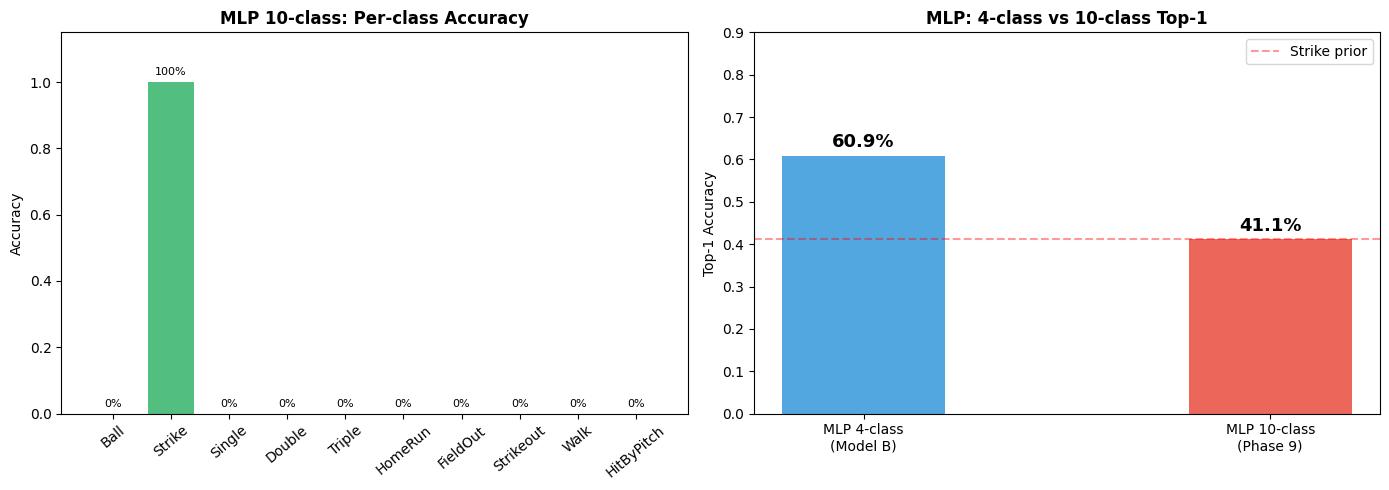

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class accuracy
acc = data['per_class_accuracy']
colors = ['#e74c3c' if a < 0.01 else '#27ae60' for a in acc]
axes[0].bar(cls10, acc, color=colors, alpha=0.8)
axes[0].set_title('MLP 10-class: Per-class Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=40)
for i, v in enumerate(acc):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=8)

# MLP 4cls (Model B) vs MLP 10cls comparison
data_b = np.load(OUTPUT_DIR / 'evaluation_b_3season.npz', allow_pickle=True)
models = ['MLP 4-class\n(Model B)', 'MLP 10-class\n(Phase 9)']
top1s = [float(data_b['top_1']), float(data['top1'])]
colors2 = ['#3498db', '#e74c3c']
bars = axes[1].bar(models, top1s, color=colors2, alpha=0.85, width=0.4)
axes[1].set_title('MLP: 4-class vs 10-class Top-1', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Top-1 Accuracy')
axes[1].set_ylim(0, 0.9)
for bar, v in zip(bars, top1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.1%}', ha='center', fontsize=13, fontweight='bold')
axes[1].axhline(0.411, color='red', linestyle='--', alpha=0.4, label='Strike prior')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. 분석

### 왜 MLP도 collapse하는가?

Cross-entropy loss 관점: 1,494,188개 train sample 중 Strike가 607,640개(40.7%).
모든 sample을 Strike로 예측 시 CE = -log(0.407) = 0.899.
더 나은 예측을 하려면 소수 클래스의 CE 감소가 다수 클래스 CE 증가를 보상해야 하는데,
77-dim feature에 discriminative signal이 부족하여 MLP가 최적해(all-Strike)에 수렴.

### 4-class에서는 왜 60.9%?
- 4개 클래스 분포: Ball 34%, Strike 27%, Foul 18%, InPlay 17% → 비교적 균형
- MLP가 각 클래스를 구분하는 non-linear boundary를 학습 가능
- 10-class는 분포가 너무 불균형하여 동일 접근으로 실패

### 해결 방안 (미래 작업)
```python
# 클래스 가중치
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(weights)
loss = F.cross_entropy(logits, y, weight=torch.tensor(weights))

# 또는 Focal Loss
# class_weight='balanced' (sklearn)
```